<a href="https://colab.research.google.com/github/aliya404/basic-data-analyst/blob/data/FinPro_Group8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Final Project Data Analyst Group 8**



In [ ]:
import pandas as pd
import numpy as np

# Import Data from Excel

In [ ]:
df_xlsx = pd.read_excel('economic_growth_data.xlsx')
df_xlsx.head()

,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%)
0,Aceh,2019,13,87,0.511488,52,-25.984078
1,Sumatra Utara,2019,10,90,5.574522,45,-6.836424
2,Sumatra Barat,2019,13,87,4.895851,49,-0.376420
3,Riau,2019,14,86,27.955008,41,-66.666893
4,Kepulauan Riau,2019,8,92,5.843278,41,-16.914731


# Data Cleaning

> Cek apakah ada data yang kosong(null)



In [ ]:
df_xlsx.isna().sum()

,0
Province,0
Year,0
Unemployment Rate (%),0
Employment Rate (%),0
Economic Growth Rate (%),0
Informal Employment Rate (%),0
Pandemic Impact on Economy (%),0


Karena tidak ada data yang null maka kita masuk ketahap selanjutnya

> Cek apakah ada data duplikat


In [ ]:
df_xlsx.duplicated(subset=['Province', 'Year'], keep=False).sum()

0



> Kemudian, Cek outliers



In [ ]:
q1 = df_xlsx.iloc[:, 2:].quantile(0.25)
q3 = df_xlsx.iloc[:, 2:].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df_xlsx = df_xlsx[~((df_xlsx.iloc[:, 2:] < lower) | (df_xlsx.iloc[:, 2:] > upper)).any(axis=1)]

In [ ]:
df_xlsx.iloc[:,2:].describe()

,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%)
count,95.000000,95.000000,95.000000,95.000000,95.000000
mean,9.242105,90.757895,13.995319,44.084211,-6.399668
std,2.819823,2.819823,13.759563,9.526741,2.916189
min,5.000000,86.000000,0.279920,30.000000,-13.971331
25%,7.000000,88.000000,3.750318,35.000000,-8.418514
50%,9.000000,91.000000,5.321434,45.000000,-6.961995
75%,12.000000,93.000000,25.006568,53.000000,-4.539245
max,14.000000,95.000000,54.715047,59.000000,-0.256634


Text(0, 0.5, 'Nilai')

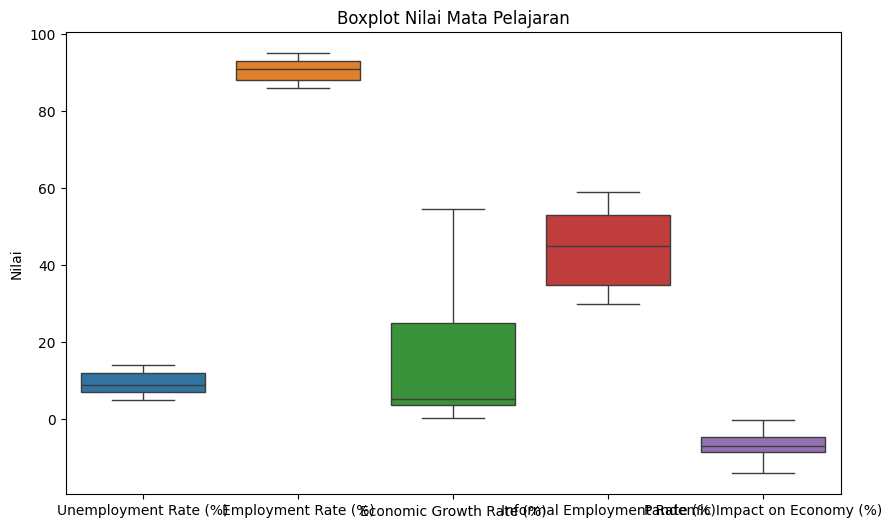

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10, 6))
sns.boxplot(data=df_xlsx.iloc[:,2:])
plt.title('Boxplot Nilai Mata Pelajaran')
plt.ylabel('Nilai')

# EDA(Exploratory Data Analysis)

> Binning Data



In [ ]:
# Pengelompokkan data provinsi di tahun 2019
df_2019 = df_xlsx[df_xlsx['Year'] == 2019]
df_2019

# Pengelompokkan data provinsi di tahun 2020
df_2020 = df_xlsx[df_xlsx['Year'] == 2020]
df_2020

# Pengelompokkan data provinsi di tahun 2021
df_2021 = df_xlsx[df_xlsx['Year'] == 2021]
df_2021.head()

,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%)
76,Aceh,2021,14,86,50.301394,57,-5.587088
77,Sumatra Utara,2021,6,94,2.120398,45,-0.821057
79,Riau,2021,10,90,23.165916,31,-8.260036
80,Kepulauan Riau,2021,14,86,39.686966,36,-13.971331
81,Jambi,2021,8,92,22.116668,44,-9.586191


Selanjutnya kita kelompokkan mana yang economic growth ratenya rendah(<25%) sedang (25%-50%) tinggi (>50%)


In [ ]:
df_low_growth = df_xlsx[df_xlsx['Economic Growth Rate (%)'] < 25]
print(len(df_low_growth))
df_low_growth.head()


71


,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%)
1,Sumatra Utara,2019,10,90,5.574522,45,-6.836424
2,Sumatra Barat,2019,13,87,4.895851,49,-0.376420
6,Bengkulu,2019,8,92,5.051887,31,-9.094177
7,Sumatra Selatan,2019,7,93,20.861153,36,-8.448765
8,Kepulauan Bangka Belitung,2019,13,87,4.208203,57,-6.349029


In [ ]:
df_medium_growth = df_xlsx[(df_xlsx['Economic Growth Rate (%)'] > 25) & (df_xlsx['Economic Growth Rate (%)'] < 50)]
print(len(df_medium_growth))
df_medium_growth

22


,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%)
5,Jambi,2019,12,88,30.699315,35,-9.684597
16,Bali,2019,6,94,30.042055,44,-7.908842
19,Kalimantan Barat,2019,5,95,25.534520,55,-4.785616
22,Kalimantan Timur,2019,9,91,29.574047,35,-7.969784
24,Sulawesi Utara,2019,8,92,30.640018,32,-9.315920
26,Sulawesi Tengah,2019,5,95,47.558030,40,-8.175845
31,Maluku Utara,2019,9,91,37.752100,47,-6.578768
32,Papua,2019,6,94,29.543252,43,-5.625413
34,Papua Tengah,2019,9,91,31.050772,34,-6.254455
46,Kepulauan Bangka Belitung,2020,5,95,28.719157,45,-5.162078


In [ ]:
df_high_growth = df_xlsx[df_xlsx['Economic Growth Rate (%)'] > 50]
print(len(df_high_growth))
df_high_growth

2


,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%)
30,Maluku,2019,7,93,54.715047,56,-3.756163
76,Aceh,2021,14,86,50.301394,57,-5.587088


In [ ]:
def economic_growth_category(row):
    if row['Economic Growth Rate (%)'] < 25:
        return 'Low'
    elif row['Economic Growth Rate (%)'] >= 25 and row['Economic Growth Rate (%)'] <= 50:
        return 'Medium'
    else:
        return 'High'


In [ ]:
df_xlsx['Economic Growth Category'] = df_xlsx.apply(economic_growth_category, axis=1)
df_xlsx.head()

,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%),Economic Growth Category
1,Sumatra Utara,2019,10,90,5.574522,45,-6.836424,Low
2,Sumatra Barat,2019,13,87,4.895851,49,-0.376420,Low
5,Jambi,2019,12,88,30.699315,35,-9.684597,Medium
6,Bengkulu,2019,8,92,5.051887,31,-9.094177,Low
7,Sumatra Selatan,2019,7,93,20.861153,36,-8.448765,Low




> Query Data



In [ ]:
df_xlsx.groupby(['Year', 'Economic Growth Category'])['Province'].count()

Year  Economic Growth Category
2019  High                         1
      Low                         21
      Medium                       9
2020  Low                         24
      Medium                       7
2021  High                         1
      Low                         26
      Medium                       6
Name: Province, dtype: int64



> Multivariate analysis



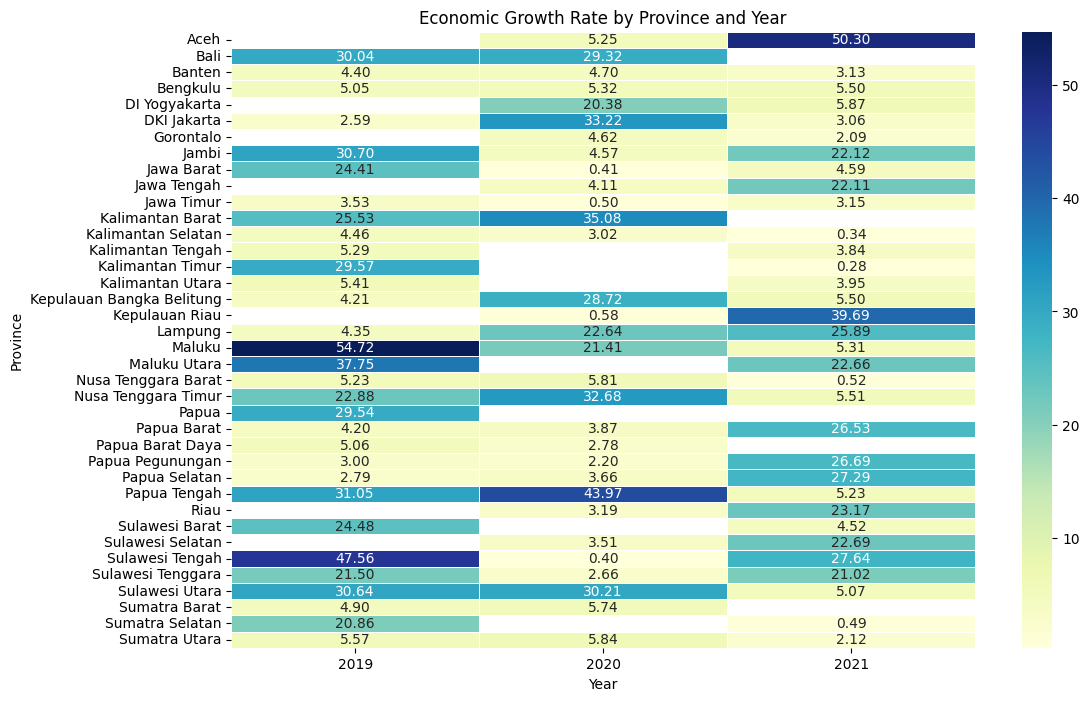

In [ ]:
# prompt: Province vs. Pandemic Impact vs. Economic Growth Rate visualisasikan dengan heatmap

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_xlsx is already loaded and processed as in the provided code

# Create the heatmap
plt.figure(figsize=(12, 8))
heatmap_data = pd.pivot_table(df_xlsx, values='Economic Growth Rate (%)', index='Province', columns='Year', aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Economic Growth Rate by Province and Year')
plt.xlabel('Year')
plt.ylabel('Province')
plt.show()

**Penurunan Drastis**: Banyak provinsi menunjukkan tingkat pertumbuhan ekonomi yang jauh lebih rendah pada tahun 2020 dibandingkan dengan 2019. Hal ini konsisten dengan dampak pandemi COVID-19 yang melanda Indonesia dan memengaruhi sektor ekonomi secara luas

**Dampak Pandemi**: Tahun 2020 adalah periode di mana hampir seluruh provinsi mengalami penurunan signifikan dalam tingkat pertumbuhan ekonomi.

**Pemulihan**: Pada 2021, beberapa provinsi mulai pulih, meskipun tidak merata. Provinsi dengan sektor ekonomi yang beragam atau yang mendapatkan dukungan kebijakan lebih baik menunjukkan pemulihan yang lebih cepat.

# Correlation Analysis

In [ ]:
num_cols = ['Unemployment Rate (%)', 'Employment Rate (%)'] # EGR dan PIE dipilih untuk dianalisis korelasinya
correlation_matrix = df_xlsx[num_cols].corr() # Menghitung matriks korelasi

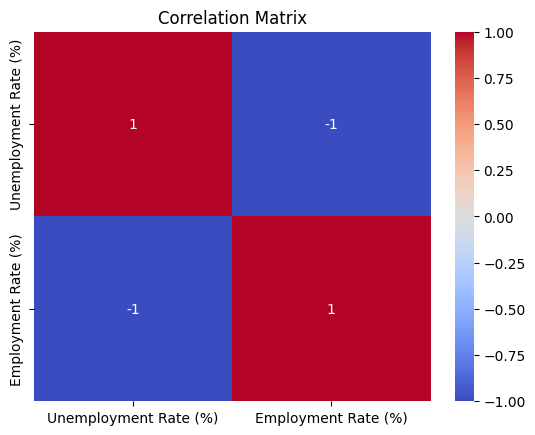

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Dari visualisasi diatas dapat kita simpulkan bahwa Employment rate dan Unemployment rate memiliki relasi yang bersifat linear berbanding terbalik, jika satu meningkat, yang lain pasti menurun.

# Data Visualization


> Pertumbuhan ekonomi dari tahun 2019-2021



<ipython-input-29-cf9c8fe3aeac>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Year', y='Economic Growth Rate (%)', data=df_xlsx, ci=None)


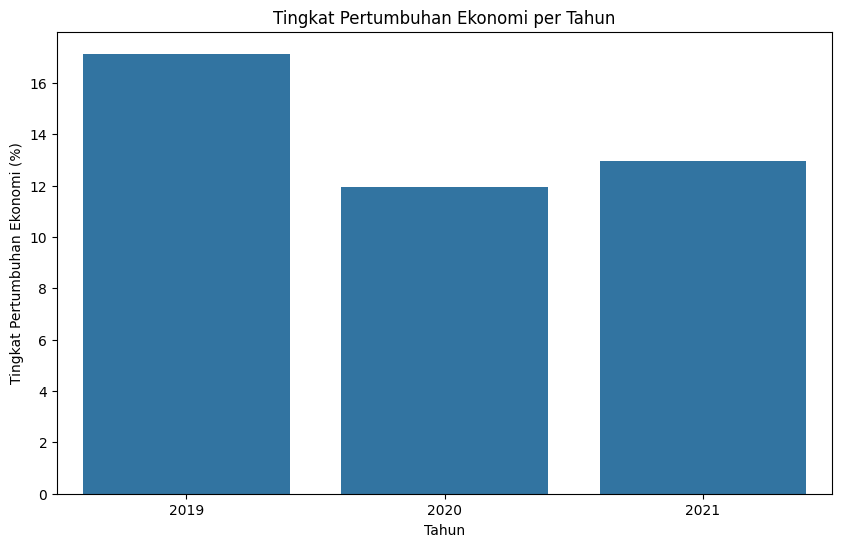

In [ ]:
# Membuat bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Economic Growth Rate (%)', data=df_xlsx, ci=None)
plt.title('Tingkat Pertumbuhan Ekonomi per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Tingkat Pertumbuhan Ekonomi (%)')
plt.show()



> Kategori pertumbuhan ekonomi disetiap tahunnya



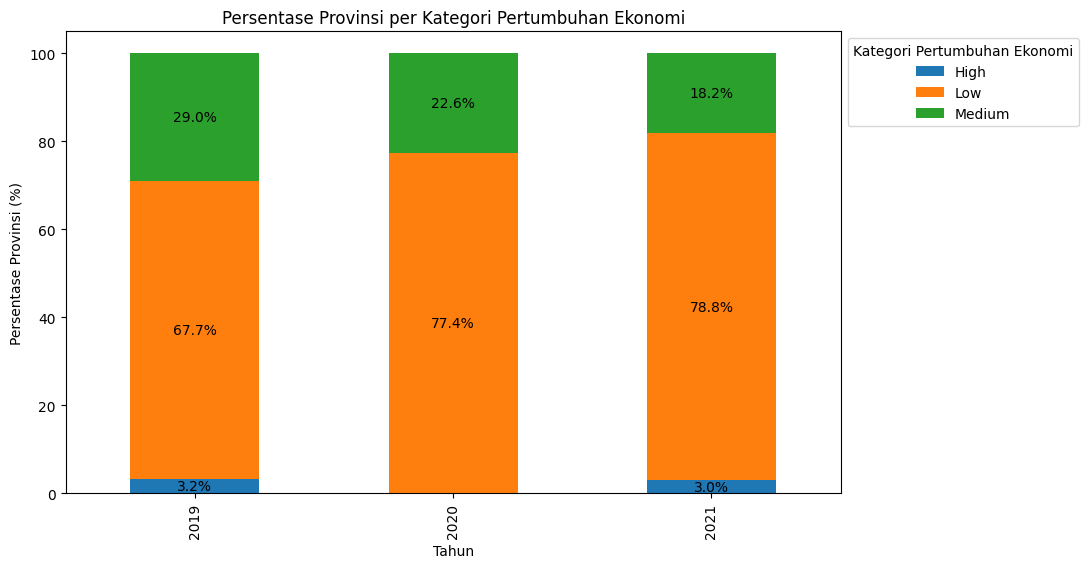

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group data and calculate percentages
category_counts = df_xlsx.groupby(['Year', 'Economic Growth Category'])['Province'].count().reset_index()
category_counts = category_counts.pivot(index='Year', columns='Economic Growth Category', values='Province')
category_counts = category_counts.div(category_counts.sum(axis=1), axis=0) * 100

# Create stacked bar plot
ax = category_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Persentase Provinsi per Kategori Pertumbuhan Ekonomi')
plt.xlabel('Tahun')
plt.ylabel('Persentase Provinsi (%)')
plt.legend(title='Kategori Pertumbuhan Ekonomi', loc='upper left', bbox_to_anchor=(1, 1))

# Annotate bars with percentages
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:  # Only annotate if height is greater than 0
        ax.annotate(f'{height:.1f}%', (x + width / 2, y + height / 2), ha='center', va='center')


plt.show()

In [ ]:
num_col = df_xlsx.select_dtypes(exclude='object')

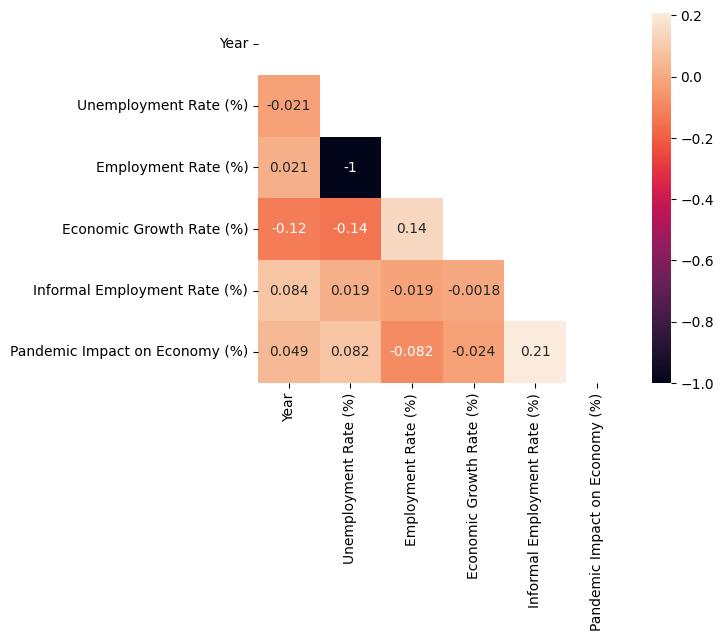

In [ ]:
corr = num_col.corr()



# Can be great to plot only a half matrix
# Generate a mask for the upper triangle
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Draw the heatmap with the mask
sns.heatmap(corr, mask=mask, square=True, annot=True)
plt.show()

In [ ]:
df_xlsx.head()

,Province,Year,Unemployment Rate (%),Employment Rate (%),Economic Growth Rate (%),Informal Employment Rate (%),Pandemic Impact on Economy (%),Economic Growth Category
1,Sumatra Utara,2019,10,90,5.574522,45,-6.836424,Low
2,Sumatra Barat,2019,13,87,4.895851,49,-0.376420,Low
5,Jambi,2019,12,88,30.699315,35,-9.684597,Medium
6,Bengkulu,2019,8,92,5.051887,31,-9.094177,Low
7,Sumatra Selatan,2019,7,93,20.861153,36,-8.448765,Low


In [ ]:
df_xlsx.groupby('Year')['Economic Growth Category'].value_counts(normalize=True)

Year  Economic Growth Category
2019  Low                         0.677419
      Medium                      0.290323
      High                        0.032258
2020  Low                         0.774194
      Medium                      0.225806
2021  Low                         0.787879
      Medium                      0.181818
      High                        0.030303
Name: proportion, dtype: float64

In [ ]:
# prompt: export data df_xlsx yang sudah diproses

# Export the processed DataFrame to an Excel file
df_xlsx.to_excel('processed_economic_growth_data.xlsx', index=False)  # Set index=False to avoid writing row indices

# Download the file (optional, but useful in Colab)
from google.colab import files
# files.download('processed_economic_growth_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

dapat kita lihat bahwa banyak provinsi yang pertumbuhan ekonomi nya rendah di tahun 2021